# Sequential dialect ID -- a Hidden Markov Model, per the user's own idea

An eleventh method, and the first in this suite that models word
**order**: every other method here (word-cluster, classifier head,
fastText-style, n-gram baselines, KNN, clustering) treats a document as
an unordered bag of features and predicts one label for the whole
document. This one is built directly from the user's own framing:

> "when predicting the next token we will have the first token belong to
> the same dialect -- if sentence starts with french next word will be
> french"

That is a first-order **Markov** assumption -- the label of word *t* is
highly predictable from the label of word *t-1* -- i.e. a **Hidden
Markov Model** with a strongly self-favoring ("sticky") transition
matrix. States = dialect classes, observations = words, and the whole
per-word label *sequence* is decoded via Viterbi, not just one label for
the document.

**Scope, per the two design decisions made before building this**
(see `../plan.md`'s "HMM-based sequential" section):
- **Within script group only** -- same convention as every other method
  here: `code_switch`/`other` decided by the deterministic script regex
  first; the HMM only resolves the harder in-group distinction (arabic
  group: `msa`/`darija`; latin group: `arabize`/`french`/`english`).
- **Emissions from a fresh word-occurrence tally over `train.jsonl`**,
  not `word_cluster`'s existing cluster-label distributions (which would
  bake in that method's confirmed weak point -- msa/darija cluster
  purity only ~0.58, barely above chance).

Pure Python/numpy -- runs in the **base** environment, no GPU/torch
needed (same as notebooks 05 and 08).


In [1]:
import json
import re
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve().parents[1]  # project root, when running from Dialect_Identification/notebooks/
DATA_DIR = ROOT / "Dialect_Identification" / "data"

SEED = 42


## 1. Script-gating + data loading (same convention as every other method here)

In [2]:
_MENTION_WITH_FRAGMENT_RE = re.compile(r"\[MENTION\](\s*-[^\s]{1,10})?")
_URL_RE = re.compile(r"\[URL\]")
_INLINE_WHITESPACE_RE = re.compile(r"[ \t]+")
_ARABIC_RE = re.compile(r"[\u0600-\u06ff\u0750-\u077f\u08a0-\u08ff\ufb50-\ufdff\ufe70-\ufeff]")
_LATIN_RE = re.compile(r"[a-zA-Z\u00c0-\u024f]")

ARABIC_CLASSES = ["msa", "darija"]
LATIN_CLASSES = ["arabize", "french", "english"]
GROUP_CLASSES = {"arabic": ARABIC_CLASSES, "latin": LATIN_CLASSES}


def clean_for_classification(text: str) -> str:
    text = _MENTION_WITH_FRAGMENT_RE.sub("", text)
    text = _URL_RE.sub("", text)
    return _INLINE_WHITESPACE_RE.sub(" ", text).strip()


def script_of(text: str) -> str:
    has_ar = bool(_ARABIC_RE.search(text))
    has_lat = bool(_LATIN_RE.search(text))
    if has_ar and has_lat:
        return "mixed"
    if has_ar:
        return "arabic"
    if has_lat:
        return "latin"
    return "other"


def load_group_rows(split: str, group: str) -> list[dict]:
    rows = []
    with (DATA_DIR / f"{split}.jsonl").open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            r = json.loads(line)
            cleaned = clean_for_classification(r["text"])
            if script_of(cleaned) != group:
                continue
            rows.append({"id": r["id"], "text": cleaned, "label": r["label"]})
    return rows


groups = {}
for group in ("arabic", "latin"):
    train_rows = load_group_rows("train", group)
    test_rows = load_group_rows("test", group)
    groups[group] = dict(train_rows=train_rows, test_rows=test_rows)
    print(f"{group}: train={len(train_rows):,}  test={len(test_rows):,}  "
          f"train label counts={Counter(r['label'] for r in train_rows)}")


arabic: train=6,660  test=1,665  train label counts=Counter({'darija': 4493, 'msa': 2167})


latin: train=4,563  test=1,142  train label counts=Counter({'arabize': 2482, 'french': 1658, 'english': 423})


## 2. Emission probabilities -- `P(word | class)`, from a fresh occurrence tally

Raw **per-occurrence** word counts (every token instance in a
class-`C` training document increments `count[word][C]`) -- deliberately
occurrence counts, not `word_cluster`'s document-presence counts, since
an emission distribution is a generative token-frequency model, the
standard way HMM/language-model emissions are estimated.

**Laplace/add-alpha smoothing** is required: most words are unseen under
most classes, and a raw MLE would assign literally impossible
(zero-probability) emissions, which breaks Viterbi outright. An unseen
word at test time falls back to the smoothed floor automatically -- no
special-cased OOV handling needed. Everything is computed in log-space
throughout (standard for HMMs -- avoids underflow over even short word
sequences).

In [3]:
ALPHA = 0.5  # Laplace/add-alpha smoothing constant


def words_of(text: str) -> list[str]:
    return text.split()


def build_emissions(train_rows: list[dict], classes: list[str]):
    """Returns (word_counts, total_tokens, vocab_size) --
    word_counts[c] is a Counter over words seen in class-c documents."""
    word_counts = {c: Counter() for c in classes}
    vocab: set[str] = set()
    for row in train_rows:
        counts = word_counts[row["label"]]
        for w in words_of(row["text"]):
            counts[w] += 1
            vocab.add(w)
    total_tokens = {c: sum(word_counts[c].values()) for c in classes}
    return word_counts, total_tokens, len(vocab)


def make_log_emission_fn(word_counts, total_tokens, vocab_size, classes):
    denom = {c: total_tokens[c] + ALPHA * vocab_size for c in classes}

    def log_emission(word: str, class_idx: int) -> float:
        c = classes[class_idx]
        count = word_counts[c].get(word, 0)
        return np.log((count + ALPHA) / denom[c])

    return log_emission


emission_state = {}
for group, gd in groups.items():
    classes = GROUP_CLASSES[group]
    word_counts, total_tokens, vocab_size = build_emissions(gd["train_rows"], classes)
    log_emission = make_log_emission_fn(word_counts, total_tokens, vocab_size, classes)
    emission_state[group] = dict(log_emission=log_emission, vocab_size=vocab_size, total_tokens=total_tokens)
    print(f"{group}: vocab={vocab_size:,}  tokens/class={total_tokens}")


arabic: vocab=61,702  tokens/class={'msa': 161649, 'darija': 92039}
latin: vocab=18,560  tokens/class={'arabize': 19115, 'french': 26213, 'english': 2887}


## 3. Transition matrix (the "sticky" prior) + initial-state distribution

`P(stay) = p_stick`, `P(switch to any other state) = (1 - p_stick) /
(num_classes - 1)` split evenly across the rest -- matches the user's own
framing directly, and transparent to reason about: there's no per-word
ground truth to count real transitions from, so this is a deliberate,
tunable prior rather than something learned from indirect supervision.
Initial-state distribution `π` is the empirical class prior from
`train.jsonl` for that group (not uniform).

In [4]:
def build_transition(num_classes: int, p_stick: float) -> np.ndarray:
    off = (1 - p_stick) / (num_classes - 1)
    mat = np.full((num_classes, num_classes), off)
    np.fill_diagonal(mat, p_stick)
    return np.log(mat)


def build_log_pi(train_rows: list[dict], classes: list[str]) -> np.ndarray:
    counts = Counter(r["label"] for r in train_rows)
    total = sum(counts.values())
    return np.log(np.array([counts.get(c, 0) / total for c in classes]))


for group, gd in groups.items():
    log_pi = build_log_pi(gd["train_rows"], GROUP_CLASSES[group])
    emission_state[group]["log_pi"] = log_pi
    print(f"{group}: log_pi={dict(zip(GROUP_CLASSES[group], np.exp(log_pi).round(3)))}")


arabic: log_pi={'msa': np.float64(0.325), 'darija': np.float64(0.675)}
latin: log_pi={'arabize': np.float64(0.544), 'french': np.float64(0.363), 'english': np.float64(0.093)}


## 4. Viterbi decoding + document-level prediction

Standard log-space Viterbi -> most likely per-word state path. Documents
here are short (median ~7-13 words for this corpus), so this is
trivially fast. **Document-level label** = majority vote over the
decoded per-word path, ties broken toward the class with the higher
empirical prior (deterministic).

In [5]:
def viterbi(words: list[str], log_pi: np.ndarray, log_trans: np.ndarray, log_emission) -> list[int]:
    n = len(words)
    num_states = len(log_pi)
    if n == 0:
        return []

    log_delta = np.empty((n, num_states))
    backptr = np.empty((n, num_states), dtype=np.int64)

    log_delta[0] = log_pi + np.array([log_emission(words[0], s) for s in range(num_states)])

    for t in range(1, n):
        emit = np.array([log_emission(words[t], s) for s in range(num_states)])
        scores = log_delta[t - 1][:, None] + log_trans  # (from_state, to_state)
        backptr[t] = scores.argmax(axis=0)
        log_delta[t] = scores.max(axis=0) + emit

    path = [int(log_delta[-1].argmax())]
    for t in range(n - 1, 0, -1):
        path.append(int(backptr[t, path[-1]]))
    path.reverse()
    return path


def path_to_label(path: list[int], classes: list[str], log_pi: np.ndarray) -> str:
    if not path:
        # Empty word list (shouldn't happen post-cleaning, but fall back to the prior)
        return classes[int(log_pi.argmax())]
    counts = Counter(path)
    max_count = max(counts.values())
    tied = [s for s, c in counts.items() if c == max_count]
    best = max(tied, key=lambda s: log_pi[s])  # tie-break: higher empirical prior
    return classes[best]


def classify_document(text: str, group: str) -> tuple[str, list[int]]:
    state = emission_state[group]
    classes = GROUP_CLASSES[group]
    words = words_of(text)
    path = viterbi(words, state["log_pi"], state["log_trans"], state["log_emission"])
    label = path_to_label(path, classes, state["log_pi"])
    return label, path


## 5. `p_stick` sweep

Same "sweep a real hyperparameter and show the curve" pattern as
notebook 07's k-sweep. Expect worse accuracy at both extremes: very low
`p_stick` degenerates toward classifying each word independently off
noisy per-word emissions (no benefit from context, the entire point of
this method); `p_stick` -> 1 degenerates toward ignoring the words
entirely and always predicting the class with the highest prior for
every position (the transition term swamps the emission term).

In [6]:
P_STICK_VALUES = [0.5, 0.7, 0.8, 0.9, 0.95, 0.99, 0.999]

sweep_results = []
for group, gd in groups.items():
    classes = GROUP_CLASSES[group]
    num_classes = len(classes)
    label_to_id = {c: i for i, c in enumerate(classes)}
    test_rows = gd["test_rows"]

    for p_stick in P_STICK_VALUES:
        emission_state[group]["log_trans"] = build_transition(num_classes, p_stick)
        y_true, y_pred = [], []
        for row in test_rows:
            pred_label, _ = classify_document(row["text"], group)
            y_true.append(row["label"])
            y_pred.append(pred_label)
        acc = sum(t == p for t, p in zip(y_true, y_pred)) / len(y_true)
        sweep_results.append({"group": group, "p_stick": p_stick, "accuracy": acc})

sweep_df = pd.DataFrame(sweep_results)
sweep_df.pivot(index="p_stick", columns="group", values="accuracy")


group,arabic,latin
p_stick,,
0.500,0.783784,0.756567
0.700,0.803003,0.780210
0.800,0.805405,0.801226
0.900,0.804204,0.807356
0.950,0.804204,0.810858
0.990,0.806006,0.816988
0.999,0.807808,0.816988


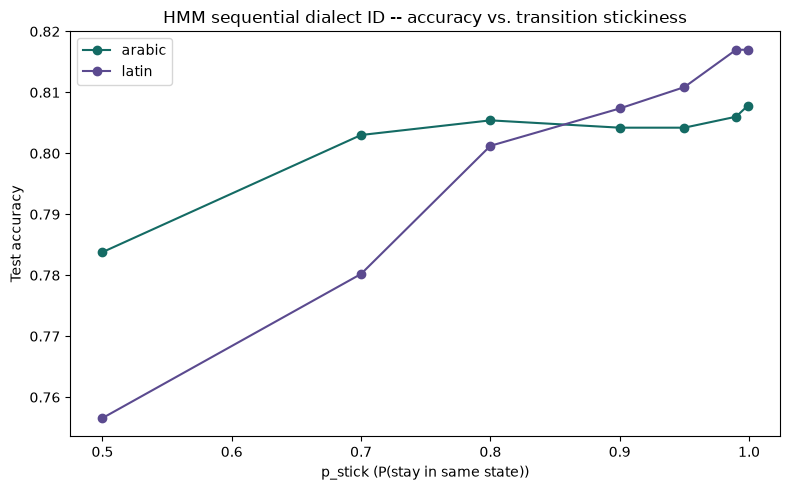

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = {"arabic": "#146b64", "latin": "#5b4a8f"}
for group in groups:
    sub = sweep_df[sweep_df["group"] == group]
    ax.plot(sub["p_stick"], sub["accuracy"], marker="o", label=group, color=colors[group])
ax.set_xlabel("p_stick (P(stay in same state))")
ax.set_ylabel("Test accuracy")
ax.set_title("HMM sequential dialect ID -- accuracy vs. transition stickiness")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Detailed evaluation at each group's best `p_stick`

In [8]:
best_p_stick = {}
final_results = {}

for group, gd in groups.items():
    classes = GROUP_CLASSES[group]
    num_classes = len(classes)
    sub = sweep_df[sweep_df["group"] == group]
    p_stick = float(sub.loc[sub["accuracy"].idxmax(), "p_stick"])
    best_p_stick[group] = p_stick
    emission_state[group]["log_trans"] = build_transition(num_classes, p_stick)

    test_rows = gd["test_rows"]
    y_true, y_pred, paths = [], [], []
    for row in test_rows:
        pred_label, path = classify_document(row["text"], group)
        y_true.append(row["label"])
        y_pred.append(pred_label)
        paths.append(path)

    acc = sum(t == p for t, p in zip(y_true, y_pred)) / len(y_true)
    final_results[group] = dict(y_true=y_true, y_pred=y_pred, paths=paths, accuracy=acc)
    print(f"\n{group}: best p_stick={p_stick}  accuracy={acc:.4f} ({sum(t == p for t, p in zip(y_true, y_pred))}/{len(y_true)})")

    print("Per-class accuracy:")
    for cname in classes:
        idx = [i for i, t in enumerate(y_true) if t == cname]
        n_correct = sum(y_pred[i] == cname for i in idx)
        print(f"  {cname:<10} {n_correct:>4}/{len(idx):<4} acc={n_correct / len(idx) if idx else float('nan'):.3f}")



arabic: best p_stick=0.999  accuracy=0.8078 (1345/1665)
Per-class accuracy:
  msa         244/542  acc=0.450
  darija     1101/1123 acc=0.980

latin: best p_stick=0.99  accuracy=0.8170 (933/1142)
Per-class accuracy:
  arabize     529/621  acc=0.852
  french      343/415  acc=0.827
  english      61/106  acc=0.575


In [9]:
def print_confusion(classes, y_true, y_pred, title):
    n = len(classes)
    idx = {c: i for i, c in enumerate(classes)}
    mat = [[0] * n for _ in range(n)]
    for t, p in zip(y_true, y_pred):
        mat[idx[t]][idx[p]] += 1
    print(f"\n{title} confusion matrix (rows=true, cols=predicted):")
    print("true\\pred" + "".join(f"{c:>12}" for c in classes))
    for i, c in enumerate(classes):
        print(f"{c:<10}" + "".join(f"{mat[i][j]:>12}" for j in range(n)))


for group, res in final_results.items():
    print_confusion(GROUP_CLASSES[group], res["y_true"], res["y_pred"], group)



arabic confusion matrix (rows=true, cols=predicted):
true\pred         msa      darija
msa                244         298
darija              22        1101

latin confusion matrix (rows=true, cols=predicted):
true\pred     arabize      french     english
arabize            529          41          51
french              63         343           9
english             43           2          61


## 7. Misclassified examples -- with the decoded per-word path

The one diagnostic unique to a sequential model: not just "what did it
predict", but "where did the decoded state actually change mid-document"
-- shown for both a few wrong predictions and a few correct ones, since
that's the direct evidence of whether the sticky-transition idea is
actually doing anything, or the model is just falling back to majority
class every time (a path that never changes state at all).

In [10]:
import random

random.seed(0)

for group, res in final_results.items():
    classes = GROUP_CLASSES[group]
    test_rows = groups[group]["test_rows"]

    wrong = [
        (row["text"], t, p, path)
        for row, t, p, path in zip(test_rows, res["y_true"], res["y_pred"], res["paths"]) if t != p
    ]
    correct_with_switch = [
        (row["text"], t, p, path)
        for row, t, p, path in zip(test_rows, res["y_true"], res["y_pred"], res["paths"])
        if t == p and len(set(path)) > 1
    ]

    print(f"\n=== {group}: {len(wrong)}/{len(test_rows)} misclassified ({len(wrong) / len(test_rows):.1%}) ===")
    for text, true_label, pred_label, path in random.sample(wrong, min(8, len(wrong))):
        words = words_of(text)
        decoded = " ".join(f"{w}/{classes[s]}" for w, s in zip(words, path))
        print(f"\n  true={true_label}  pred={pred_label}")
        print(f"  path: {decoded[:200]}{'...' if len(decoded) > 200 else ''}")

    print(f"\n--- {group}: {len(correct_with_switch)}/{len(test_rows)} correct predictions where the decoded path actually changed state ---")
    for text, true_label, pred_label, path in random.sample(correct_with_switch, min(4, len(correct_with_switch))):
        words = words_of(text)
        decoded = " ".join(f"{w}/{classes[s]}" for w, s in zip(words, path))
        print(f"\n  true=pred={true_label}")
        print(f"  path: {decoded[:200]}{'...' if len(decoded) > 200 else ''}")



=== arabic: 320/1665 misclassified (19.2%) ===

  true=msa  pred=darija
  path: بلانا/darija ربي/darija بجارة/darija السوء/darija

  true=msa  pred=darija
  path: اسم/darija معلمتي/darija في/darija السنة/darija الاولى/darija ابتدائي/darija :/darija ناظور/darija .../darija بارك/darija الله/darija فيك/darija على/darija حسن/darija المتابعة/darija وطيب/darija التو/...

  true=msa  pred=darija
  path: جماعة/darija البيام/darija

  true=msa  pred=darija
  path: 50.../darija سنة...حبس...في.حقهم/darija

  true=msa  pred=darija
  path: آمين/darija يا/darija رب/darija بارك/darija الله/darija فيك/darija أخي/darija إياد/darija

  true=msa  pred=darija
  path: تحدث/darija الشخص/darija بالعربية/darija الفصحى/darija البليغة/darija دليل/darija على/darija مدى/darija تقدمه/darija الفكري/darija

  true=msa  pred=darija
  path: امنية/darija حياتي/darija حفظ/darija القران/darija الكريم/darija لكن/darija حفظي/darija بطيء/darija جدا/darija ارجو/darija طريقة/darija اخرى/darija وليس/darija في/darija 45/darija

## 8. Compared against every other method tried on this task

In [11]:
comparison = {
    "regex + real fastText lid.176": (0.340, 0.630),
    "word-cluster baseline (cluster-scored)": (0.562, 0.562),
    "fastText-style (cluster-scored)": (0.582, 0.582),
    "regex/marker-word baseline": (0.699, 0.748),
    "cluster + 200 human-labeled prototypes": (0.701, 0.810),
    "Cavnar & Trenkle (n-gram profiles)": (0.754, 0.844),
    "KNN on sentence embeddings (best of 32 configs)": (0.770, 0.835),
    "cluster + majority vote (best k)": (0.796, 0.846),
    "classifier head (transformer)": (0.819, 0.863),
    "n-gram + SVM-RBF (best of notebook 04)": (0.833, 0.881),
    "HMM sequential (this notebook)": (final_results["arabic"]["accuracy"], final_results["latin"]["accuracy"]),
}

print(f"{'method':<50}{'arabic':>10}{'latin':>10}")
for name, (a, l) in sorted(comparison.items(), key=lambda kv: kv[1][0]):
    marker = "  <== this notebook" if name.startswith("HMM") else ""
    print(f"{name:<50}{a:>10.3f}{l:>10.3f}{marker}")


method                                                arabic     latin
regex + real fastText lid.176                          0.340     0.630
word-cluster baseline (cluster-scored)                 0.562     0.562
fastText-style (cluster-scored)                        0.582     0.582
regex/marker-word baseline                             0.699     0.748
cluster + 200 human-labeled prototypes                 0.701     0.810
Cavnar & Trenkle (n-gram profiles)                     0.754     0.844
KNN on sentence embeddings (best of 32 configs)        0.770     0.835
cluster + majority vote (best k)                       0.796     0.846
HMM sequential (this notebook)                         0.808     0.817  <== this notebook
classifier head (transformer)                          0.819     0.863
n-gram + SVM-RBF (best of notebook 04)                 0.833     0.881
